# Phase 2: Feature Engineering for E-commerce ML

**Goal:** Create ML-ready features from your clean e-commerce data

**Tools:** Python, Pandas, NumPy, SQL, Matplotlib, Seaborn

**What is Feature Engineering?**
Feature engineering is the process of creating new variables (features) from raw data that help machine learning models learn patterns better. Good features are often more important than complex models!

---

# Table of Contents

- [Step 1: Setup & Data Loading](#1-setup--data-loading)
- [Step 2: RFM Analysis (Recency, Frequency, Monetary)](#2-rfm-analysis-recency-frequency-monetary)
- [Step 3: Customer Behaviour Features](#3-customer-behaviour-features)
- [Step 4: Product Features](#4-product-features)
- [Step 5: Time-Based Features](#5-time-based-features)
- [Step 6: Feature Analysis & Selection](#6-feature-analysis--selection)
- [Step 7: Final Feature Store](#7-final-feature-store)

---

<a id='setup'></a>
# Step 1: Setup & Data Loading

## Objectives:
- Connect to Step 1 database
- Load all necessary tables
- Prepare data for feature engineering

## What We'll Build:
By the end of this week, you'll have created:
- **RFM Scores** - How recently, frequently, and how much customers buy
- **Behavioural Features** - Purchase patterns, preferences, habits
- **Product Features** - Popularity, revenue contribution, categories
- **Temporal Features** - Seasonality, day-of-week patterns, time gaps
- **Aggregate Features** - Customer lifetime value, average basket size, etc.

In [34]:
# Import libraries
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set visualisation style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print(" All libraries imported!")

 All libraries imported!


In [35]:
# Connect to database
conn = sqlite3.connect('ecommerce.db')
print(" Connected to database")

# Load all tables
customers = pd.read_sql_query("SELECT * FROM customers", conn)
products = pd.read_sql_query("SELECT * FROM products", conn)
invoices = pd.read_sql_query("SELECT * FROM invoices", conn)
invoice_items = pd.read_sql_query("SELECT * FROM invoice_items", conn)

print(f"\n Data Loaded:")
print(f"   • Customers: {len(customers):,} rows")
print(f"   • Products: {len(products):,} rows")
print(f"   • Invoices: {len(invoices):,} rows")
print(f"   • Invoice Items: {len(invoice_items):,} rows")

# Convert dates
customers['first_purchase_date'] = pd.to_datetime(customers['first_purchase_date'])
customers['last_purchase_date'] = pd.to_datetime(customers['last_purchase_date'])
invoices['invoice_date'] = pd.to_datetime(invoices['invoice_date'])

print("\n Date columns converted")

 Connected to database

 Data Loaded:
   • Customers: 4,367 rows
   • Products: 3,684 rows
   • Invoices: 22,178 rows
   • Invoice Items: 406,545 rows

 Date columns converted


In [36]:
# Quick data preview
print(" Sample Customers:")
display(customers.head(3))

print("\n Sample Invoices:")
display(invoices.head(3))

 Sample Customers:


,customer_id,country,first_purchase_date,last_purchase_date,total_orders
0,12346,United Kingdom,2011-01-18 10:01:00,2011-01-18 10:17:00,2
1,12347,Iceland,2010-12-07 14:57:00,2011-12-07 15:52:00,7
2,12348,Finland,2010-12-16 19:09:00,2011-09-25 13:13:00,4



 Sample Invoices:


,invoice_no,customer_id,invoice_date,country,total_amount,total_items
0,536365,17850,2010-12-01 08:26:00,United Kingdom,139.12,40
1,536366,17850,2010-12-01 08:28:00,United Kingdom,22.20,12
2,536367,13047,2010-12-01 08:34:00,United Kingdom,278.73,83


---
<a id='rfm'></a>
# Step 2: RFM Analysis (Recency, Frequency, Monetary)

## What is RFM?
RFM is a classic customer segmentation technique:
- **Recency (R):** How recently did the customer make a purchase?
- **Frequency (F):** How often do they purchase?
- **Monetary (M):** How much do they spend?

## Why RFM?
- Simple but powerful
- Proven to predict customer behaviour
- Easy to interpret for business stakeholders
- Foundation for customer segmentation

In [37]:
# Set reference date (use the most recent date in data + 1 day)
reference_date = invoices['invoice_date'].max() + timedelta(days=1)
print(f" Reference Date: {reference_date.strftime('%d-%m-%Y')}")

# Calculate RFM values for each customer
rfm = customers.merge(
    invoices.groupby('customer_id').agg({
        'total_amount': 'sum',
        'invoice_no': 'count'
    }).reset_index(),
    on='customer_id',
    how='left'
)

# Calculate Recency (days since last purchase)
rfm['recency'] = (reference_date - rfm['last_purchase_date']).dt.days

# Frequency (number of orders)
rfm['frequency'] = rfm['invoice_no']

# Monetary (total spend)
rfm['monetary'] = rfm['total_amount']

# Select RFM columns
rfm_features = rfm[['customer_id', 'recency', 'frequency', 'monetary']].copy()

print("\n RFM Features Created:")
display(rfm_features)
print("\n RFM Features' statistics:")
display(rfm_features.describe())

print("\n RFM analysis complete!")

 Reference Date: 10-12-2011

 RFM Features Created:


,customer_id,recency,frequency,monetary
0,12346,326,2,0.00
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40
...,...,...,...,...
4362,18280,278,1,180.60
4363,18281,181,1,80.82
4364,18282,8,3,176.60
4365,18283,4,16,2094.88



 RFM Features' statistics:


,customer_id,recency,frequency,monetary
count,4367.000000,4367.000000,4367.000000,4367.000000
mean,15301.406916,92.029082,5.078544,1900.022611
std,1721.949901,100.806243,9.336338,8223.912836
min,12346.000000,1.000000,1.000000,-4287.630000
25%,13814.500000,17.000000,1.000000,293.275000
50%,15303.000000,50.000000,3.000000,648.690000
75%,16779.500000,143.000000,5.000000,1612.460000
max,18287.000000,374.000000,248.000000,279489.020000



 RFM analysis complete!


In [38]:
rfm

,customer_id,country,first_purchase_date,last_purchase_date,total_orders,total_amount,invoice_no,recency,frequency,monetary
0,12346,United Kingdom,2011-01-18 10:01:00,2011-01-18 10:17:00,2,0.00,2,326,2,0.00
1,12347,Iceland,2010-12-07 14:57:00,2011-12-07 15:52:00,7,4310.00,7,2,7,4310.00
2,12348,Finland,2010-12-16 19:09:00,2011-09-25 13:13:00,4,1797.24,4,75,4,1797.24
3,12349,Italy,2011-11-21 09:51:00,2011-11-21 09:51:00,1,1757.55,1,19,1,1757.55
4,12350,Norway,2011-02-02 16:01:00,2011-02-02 16:01:00,1,334.40,1,310,1,334.40
...,...,...,...,...,...,...,...,...,...,...
4362,18280,United Kingdom,2011-03-07 09:52:00,2011-03-07 09:52:00,1,180.60,1,278,1,180.60
4363,18281,United Kingdom,2011-06-12 10:53:00,2011-06-12 10:53:00,1,80.82,1,181,1,80.82
4364,18282,United Kingdom,2011-08-05 13:35:00,2011-12-02 11:43:00,3,176.60,3,8,3,176.60
4365,18283,United Kingdom,2011-01-06 14:14:00,2011-12-06 12:02:00,16,2094.88,16,4,16,2094.88


In [39]:
# Create RFM Scores (1-5 scale, 5 = best)
# Lower recency is better → higher score
# Higher frequency is better → higher score
# Higher monetary is better → higher score

rfm_features['r_score'] = pd.qcut(rfm_features['recency'], q=5, labels=[5, 4, 3, 2, 1])
rfm_features['f_score'] = pd.qcut(rfm_features['frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])
rfm_features['m_score'] = pd.qcut(rfm_features['monetary'], q=5, labels=[1, 2, 3, 4, 5])

# Create RFM segment (concatenate scores)
rfm_features['rfm_segment'] = (rfm_features['r_score'].astype(str) + 
                                rfm_features['f_score'].astype(str) + 
                                rfm_features['m_score'].astype(str))

# Create RFM score (average of R, F, M)
rfm_features['rfm_score'] = (rfm_features['r_score'].astype(int) + 
                             rfm_features['f_score'].astype(int) + 
                             rfm_features['m_score'].astype(int)) / 3

print("\n RFM Scores Created!")
print("\nTop 10 Customers by RFM Score:")
display(rfm_features.nlargest(10, 'rfm_score')[['customer_id', 'recency', 'frequency', 'monetary', 'rfm_score']])

print("\nLast 10 Customers by RFM Score:")
display(rfm_features.nsmallest(10, 'rfm_score')[['customer_id', 'recency', 'frequency', 'monetary', 'rfm_score']])

print("\n Interpretation:")
print("   • RFM Score 5.0 = Best customers (recent, frequent, high-value)")
print("   • RFM Score 1.0 = At-risk customers (not recent, infrequent, low-value)")


 RFM Scores Created!

Top 10 Customers by RFM Score:


,customer_id,recency,frequency,monetary,rfm_score
15,12362,3,13,5154.58,5.0
55,12417,3,12,3578.80,5.0
74,12437,2,19,4896.66,5.0
99,12471,2,49,18740.92,5.0
104,12476,1,20,6546.58,5.0
114,12490,5,10,5417.93,5.0
144,12524,9,8,4485.72,5.0
166,12553,8,14,3652.25,5.0
178,12569,2,35,4064.99,5.0
190,12583,3,18,7187.34,5.0



Last 10 Customers by RFM Score:


,customer_id,recency,frequency,monetary,rfm_score
6,12353,204,1,89.00,1.0
14,12361,287,1,189.90,1.0
42,12401,303,1,84.30,1.0
43,12402,323,1,225.60,1.0
76,12441,367,1,173.55,1.0
124,12503,338,1,-1126.00,1.0
126,12505,301,1,-4.50,1.0
127,12506,233,1,73.50,1.0
130,12509,284,1,176.50,1.0
164,12551,358,1,168.00,1.0



 Interpretation:
   • RFM Score 5.0 = Best customers (recent, frequent, high-value)
   • RFM Score 1.0 = At-risk customers (not recent, infrequent, low-value)


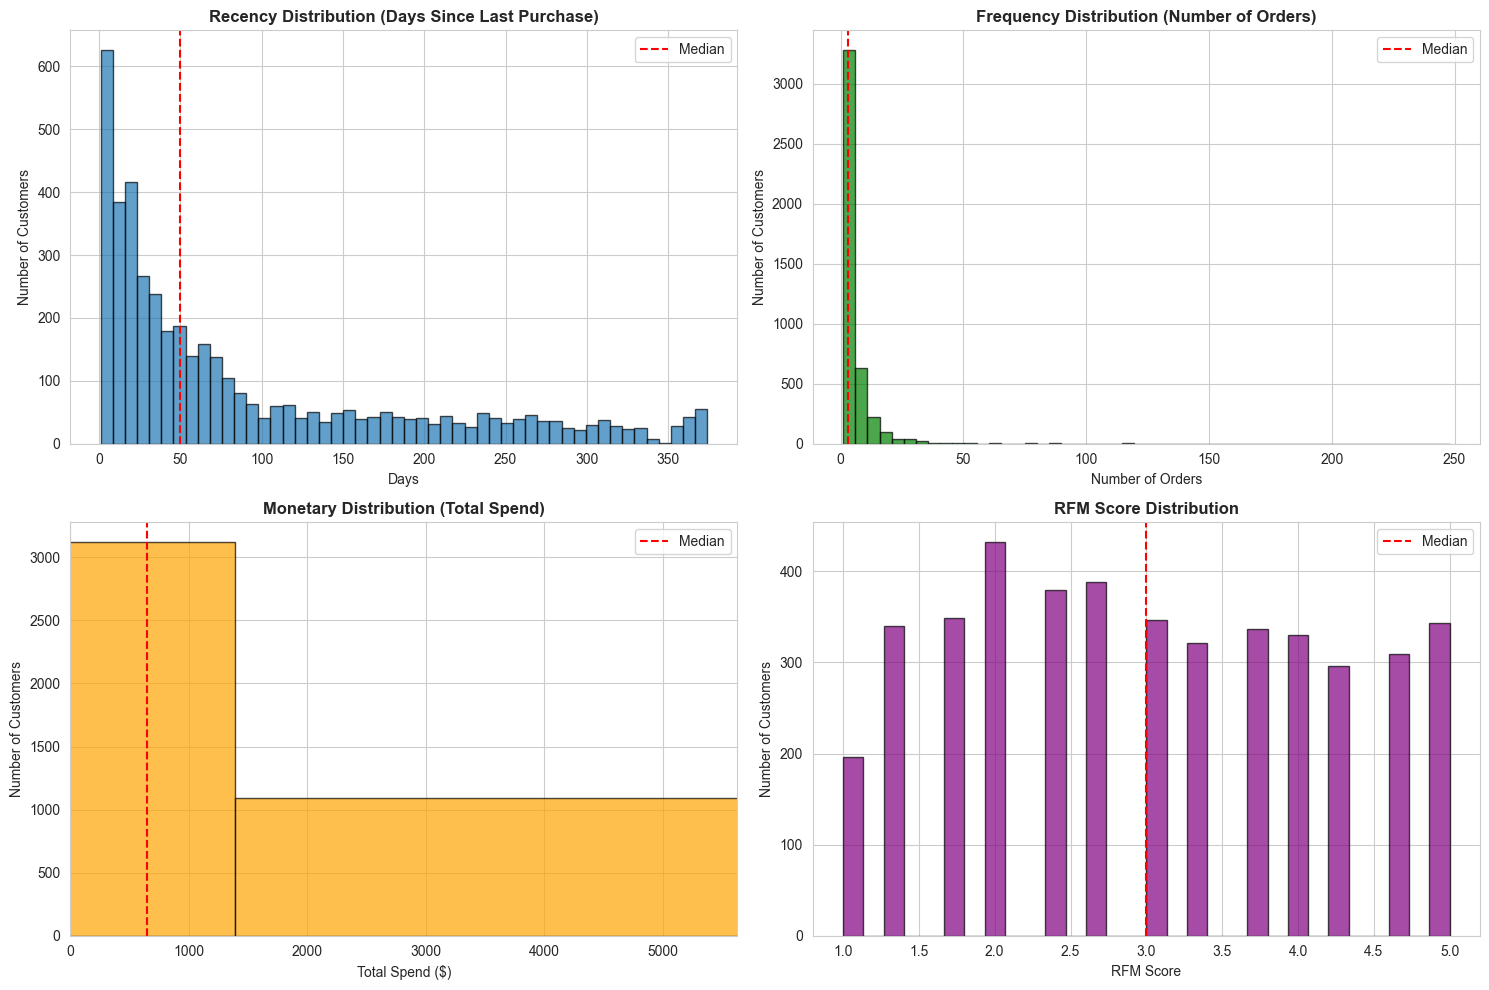


 Visualisations saved!


In [40]:
# Visualize RFM distributions
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Recency
axes[0, 0].hist(rfm_features['recency'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Recency Distribution (Days Since Last Purchase)', fontweight='bold')
axes[0, 0].set_xlabel('Days')
axes[0, 0].set_ylabel('Number of Customers')
axes[0, 0].axvline(rfm_features['recency'].median(), color='red', linestyle='--', label='Median')
axes[0, 0].legend()

# Frequency
axes[0, 1].hist(rfm_features['frequency'], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[0, 1].set_title('Frequency Distribution (Number of Orders)', fontweight='bold')
axes[0, 1].set_xlabel('Number of Orders')
axes[0, 1].set_ylabel('Number of Customers')
axes[0, 1].axvline(rfm_features['frequency'].median(), color='red', linestyle='--', label='Median')
axes[0, 1].legend()

# Monetary
axes[1, 0].hist(rfm_features['monetary'], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1, 0].set_title('Monetary Distribution (Total Spend)', fontweight='bold')
axes[1, 0].set_xlabel('Total Spend ($)')
axes[1, 0].set_ylabel('Number of Customers')
axes[1, 0].axvline(rfm_features['monetary'].median(), color='red', linestyle='--', label='Median')
axes[1, 0].legend()
axes[1, 0].set_xlim(0, rfm_features['monetary'].quantile(0.95))

# RFM Score
axes[1, 1].hist(rfm_features['rfm_score'], bins=30, edgecolor='black', alpha=0.7, color='purple')
axes[1, 1].set_title('RFM Score Distribution', fontweight='bold')
axes[1, 1].set_xlabel('RFM Score')
axes[1, 1].set_ylabel('Number of Customers')
axes[1, 1].axvline(rfm_features['rfm_score'].median(), color='red', linestyle='--', label='Median')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('rfm_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Visualisations saved!")

---
<a id='customer-features'></a>
# Step 3: Customer Behaviour Features

## What are Behavioural Features?
These capture **how** customers shop:
- Purchase patterns (weekday vs weekend)
- Average basket size
- Product diversity
- Time between purchases
- Customer tenure

## Why These Matter:
Behavioural features often reveal hidden patterns that predict future actions!

In [41]:
# Calculate customer behavioural features
print("Engineering customer behaviour features...\n")

# 1. Average Order Value (AOV)
customer_features = rfm_features[['customer_id', 'recency', 'frequency', 'monetary', 'rfm_score']].copy()
customer_features['avg_order_value'] = customer_features['monetary'] / customer_features['frequency']

# 2. Customer Tenure (days as customer)
tenure = customers[['customer_id', 'first_purchase_date', 'last_purchase_date']].copy()
tenure['tenure_days'] = (tenure['last_purchase_date'] - tenure['first_purchase_date']).dt.days
customer_features = customer_features.merge(tenure[['customer_id', 'tenure_days']], on='customer_id')

# 3. Average Days Between Purchases
customer_features['avg_days_between_purchases'] = customer_features['tenure_days'] / (customer_features['frequency'] - 1)
customer_features['avg_days_between_purchases'].fillna(0, inplace=True)  # For single-purchase customers

# 4. Unique Products Purchased
unique_products = invoice_items.merge(invoices[['invoice_no', 'customer_id']], on='invoice_no')
unique_products_per_customer = unique_products.groupby('customer_id')['stock_code'].nunique().reset_index()
unique_products_per_customer.columns = ['customer_id', 'unique_products_purchased']
customer_features = customer_features.merge(unique_products_per_customer, on='customer_id', how='left')

# 5. Average Items Per Order
items_per_order = invoices.groupby('customer_id')['total_items'].mean().reset_index()
items_per_order.columns = ['customer_id', 'avg_items_per_order']
customer_features = customer_features.merge(items_per_order, on='customer_id', how='left')

# 6. Product Diversity Ratio (unique products / total orders)
customer_features['product_diversity_ratio'] = (customer_features['unique_products_purchased'] / 
                                                customer_features['frequency'])

print(" Customer behavioural features created!")
print(f"\n Total Features: {customer_features.shape[1]} columns")
print("\nFeature List:")
for col in customer_features.columns:
    print(f"   • {col}")

Engineering customer behaviour features...

 Customer behavioural features created!

 Total Features: 11 columns

Feature List:
   • customer_id
   • recency
   • frequency
   • monetary
   • rfm_score
   • avg_order_value
   • tenure_days
   • avg_days_between_purchases
   • unique_products_purchased
   • avg_items_per_order
   • product_diversity_ratio


In [42]:
# Preview customer features
print("\n Sample Customer Features:")
display(customer_features.head(10))

print("\n Feature Statistics:")
display(customer_features.describe())


 Sample Customer Features:


,customer_id,recency,frequency,monetary,rfm_score,avg_order_value,tenure_days,avg_days_between_purchases,unique_products_purchased,avg_items_per_order,product_diversity_ratio
0,12346,326,2,0.00,1.333333,0.000000,0,0.000000,1,0.000000,0.500000
1,12347,2,7,4310.00,4.666667,615.714286,365,60.833333,103,351.142857,14.714286
2,12348,75,4,1797.24,3.000000,449.310000,282,94.000000,22,585.250000,5.500000
3,12349,19,1,1757.55,3.000000,1757.550000,0,NaN,73,631.000000,73.000000
4,12350,310,1,334.40,1.333333,334.400000,0,NaN,17,197.000000,17.000000
5,12352,36,11,1545.41,4.000000,140.491818,260,26.000000,59,42.727273,5.363636
6,12353,204,1,89.00,1.000000,89.000000,0,NaN,4,20.000000,4.000000
7,12354,232,1,1079.40,2.000000,1079.400000,0,NaN,58,530.000000,58.000000
8,12355,214,1,459.40,1.333333,459.400000,0,NaN,13,240.000000,13.000000
9,12356,23,3,2811.43,4.000000,937.143333,302,151.000000,53,530.333333,17.666667



 Feature Statistics:


,customer_id,recency,frequency,monetary,rfm_score,avg_order_value,tenure_days,avg_days_between_purchases,unique_products_purchased,avg_items_per_order,product_diversity_ratio
count,4367.000000,4367.000000,4367.000000,4367.000000,4367.000000,4367.000000,4367.000000,3055.000000,4367.000000,4367.000000,4367.000000
mean,15301.406916,92.029082,5.078544,1900.022611,3.004274,315.960570,133.490268,60.435261,61.227616,193.953375,16.635058
std,1721.949901,100.806243,9.336338,8223.912836,1.197877,361.495065,132.875616,61.694267,85.460181,261.432978,16.023132
min,12346.000000,1.000000,1.000000,-4287.630000,1.000000,-4287.630000,0.000000,0.000000,1.000000,-244.000000,0.166667
25%,13814.500000,17.000000,1.000000,293.275000,2.000000,151.982500,0.000000,21.000000,15.000000,78.000000,6.500000
50%,15303.000000,50.000000,3.000000,648.690000,3.000000,236.763333,98.000000,41.125000,35.000000,137.000000,12.000000
75%,16779.500000,143.000000,5.000000,1612.460000,4.000000,370.832143,256.000000,76.000000,77.000000,232.052632,21.500000
max,18287.000000,374.000000,248.000000,279489.020000,5.000000,6207.670000,373.000000,365.000000,1794.000000,7824.000000,219.000000


---
<a id='product-features'></a>
# Step 4. Product Features

## Product-Level Features:
- Popularity metrics
- Revenue contribution
- Price positioning
- Purchase velocity

**Note:** Product features are useful for recommendation systems and inventory optimisation!

<!-- ---
<a id='product-features'></a>
# Step 4: Product Features

## Product-Level Features:
- Popularity metrics
- Revenue contribution
- Price positioning
- Purchase velocity

**Note:** Product features are useful for recommendation systems and inventory optimisation! -->

In [43]:
# Product feature engineering code
print("Ready for product feature engineering!")

Ready for product feature engineering!


 PRODUCT FEATURE ENGINEERING

1️⃣ Calculating Product Popularity Metrics...
   ✓ Calculated popularity for 3684 products

2️⃣ Calculating Revenue Contribution...
   ✓ Total revenue tracked: $8,297,398.74
   ✓ Top 20% products contribute: 774 products

3️⃣ Calculating Price Positioning...
   ✓ Budget products: 1256
   ✓ Mid-range products: 1228
   ✓ Premium products: 1200

4️⃣ Calculating Purchase Velocity...

4️⃣ Calculating Purchase Velocity (Global Time Window)...
   ✓ Dataset duration: 374 days
   ✓ Average purchase velocity: 0.2877 orders/day
   ✓ Max purchase velocity: 5.4011 orders/day

5️⃣ Creating Product Performance Categories...
   ✓ High performers: 737
   ✓ Medium performers: 1474
   ✓ Low performers: 1473

6️⃣ Calculating Repeat Purchase Rate...
   ✓ Average repeat purchase rate: 18.7%

 PRODUCT FEATURES SUMMARY

 Total products analyzed: 3684
 Features created: 14 columns

 Feature List:
   • stock_code
   • num_orders_x
   • total_quantity_sold
   • total_revenue
   • un

,stock_code,total_revenue,total_quantity_sold,unique_customers,price_category,performance_category
0,22423,132844.90,11543,885,Premium,High Performer
1,85123A,93979.20,34204,858,Mid-Range,High Performer
2,85099B,83236.76,45066,636,Mid-Range,High Performer
3,47566,67687.53,15023,708,Premium,High Performer
4,POST,66710.24,3002,379,Premium,High Performer
5,84879,56462.04,35292,677,Mid-Range,High Performer
6,23084,51137.80,27094,450,Mid-Range,High Performer
7,22502,46980.95,1413,175,Premium,High Performer
8,79321,45936.81,9570,205,Premium,High Performer
9,22086,41500.48,15164,615,Mid-Range,High Performer



8️⃣ Visualizing Product Features...


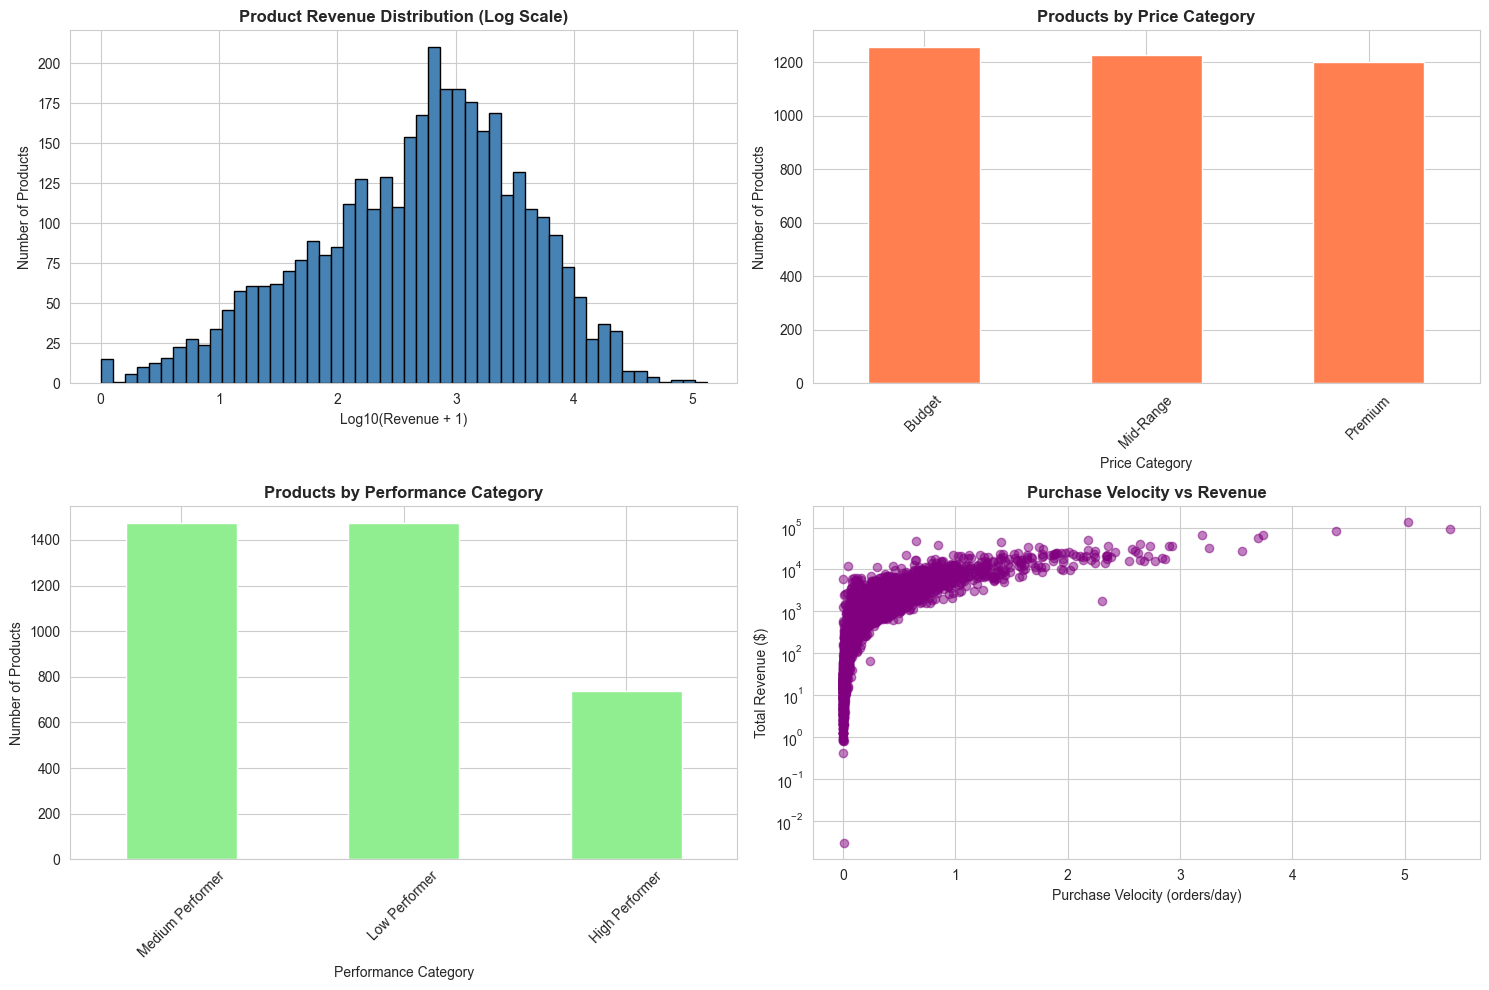

 Visualisation saved: product_features_analysis.png

9️⃣ Saving Product Features...
 Saved: product_features.csv
 Saved to database: product_features table

 PRODUCT FEATURES COMPLETE!


In [44]:
# ============================================================
# PRODUCT FEATURES
# ============================================================

print("="*60)
print(" PRODUCT FEATURE ENGINEERING")
print("="*60)

# Load data if not already loaded
# (Assuming you have invoice_items and products tables loaded)

print("\n1️⃣ Calculating Product Popularity Metrics...")

# Product popularity features
product_features = invoice_items.groupby('stock_code').agg({
    'invoice_no': 'nunique',  # Number of unique orders
    'quantity': 'sum',        # Total quantity sold
    'line_total': 'sum'       # Total revenue
}).reset_index()

product_features.columns = ['stock_code', 'num_orders', 'total_quantity_sold', 'total_revenue']

# Add number of unique customers who bought each product
invoice_items = invoice_items.merge(
    invoices[['invoice_no', 'customer_id', 'invoice_date']],
    on='invoice_no',
    how='left'
)

customers_per_product = invoice_items.groupby('stock_code')['customer_id'].nunique().reset_index()
customers_per_product.columns = ['stock_code', 'unique_customers']
product_features = product_features.merge(customers_per_product, on='stock_code')

print(f"   ✓ Calculated popularity for {len(product_features)} products")

# ============================================================
print("\n2️⃣ Calculating Revenue Contribution...")

# Revenue contribution (% of total revenue)
total_revenue = product_features['total_revenue'].sum()
product_features['revenue_contribution_pct'] = (
    product_features['total_revenue'] / total_revenue * 100
)

# Cumulative revenue contribution (for Pareto analysis)
product_features = product_features.sort_values('total_revenue', ascending=False)
product_features['cumulative_revenue_pct'] = (
    product_features['revenue_contribution_pct'].cumsum()
)

print(f"   ✓ Total revenue tracked: ${total_revenue:,.2f}")
print(f"   ✓ Top 20% products contribute: {product_features[product_features['cumulative_revenue_pct'] <= 80].shape[0]} products")

# ============================================================
print("\n3️⃣ Calculating Price Positioning...")

# Merge with products table to get unit prices
product_features = product_features.merge(
    products[['stock_code', 'avg_unit_price']], 
    on='stock_code', 
    how='left'
)

# Calculate average order value per product
product_features['avg_order_value'] = (
    product_features['total_revenue'] / product_features['num_orders']
)

# Price positioning categories
price_percentiles = product_features['avg_unit_price'].quantile([0.33, 0.67])
product_features['price_category'] = pd.cut(
    product_features['avg_unit_price'],
    bins=[0, price_percentiles.iloc[0], price_percentiles.iloc[1], float('inf')],
    labels=['Budget', 'Mid-Range', 'Premium']
)

print(f"   ✓ Budget products: {(product_features['price_category'] == 'Budget').sum()}")
print(f"   ✓ Mid-range products: {(product_features['price_category'] == 'Mid-Range').sum()}")
print(f"   ✓ Premium products: {(product_features['price_category'] == 'Premium').sum()}")

# ============================================================
print("\n4️⃣ Calculating Purchase Velocity...")

# Get date range for each product (first and last purchase)
'''product_dates = invoice_items.merge(
    invoices[['invoice_no', 'invoice_date']], 
    on='invoice_no'
).groupby('stock_code').agg({
    'invoice_date': ['min', 'max', 'count']
}).reset_index()
'''

print("\n4️⃣ Calculating Purchase Velocity (Global Time Window)...")

# Ensure invoice_date exists in invoice_items
if 'invoice_date' not in invoice_items.columns:
    invoice_items = invoice_items.merge(
        invoices[['invoice_no', 'invoice_date']],
        on='invoice_no',
        how='left'
    )

# Make sure invoice_date is datetime
invoice_items['invoice_date'] = pd.to_datetime(invoice_items['invoice_date'])

# Calculate Global Dataset Duration
global_start_date = invoice_items['invoice_date'].min()
global_end_date   = invoice_items['invoice_date'].max()

global_days = (global_end_date - global_start_date).days + 1

print(f"   ✓ Dataset duration: {global_days} days")

# Calculate Number of Unique Orders per Product
product_orders = (
    invoice_items
    .groupby('stock_code')['invoice_no']
    .nunique()
    .reset_index()
)

product_orders.columns = ['stock_code', 'num_orders']

# Calculate Purchase Velocity
product_orders['purchase_velocity'] = (
    product_orders['num_orders'] / global_days
)

# Merge Back to Product Features
product_features = product_features.merge(
    product_orders,
    on='stock_code',
    how='left'
)

# Fill missing values (products with no orders in window)
product_features['purchase_velocity'] = (
    product_features['purchase_velocity'].fillna(0)
)

print(f"   ✓ Average purchase velocity: {product_features['purchase_velocity'].mean():.4f} orders/day")
print(f"   ✓ Max purchase velocity: {product_features['purchase_velocity'].max():.4f} orders/day")

# ============================================================
print("\n5️⃣ Creating Product Performance Categories...")

# Categorize products based on performance
# High performers: Top 20% by revenue
# Medium performers: 20-60%
# Low performers: Bottom 40%

revenue_ranks = product_features['total_revenue'].rank(pct=True, ascending=True)
product_features['performance_category'] = pd.cut(
    revenue_ranks,
    bins=[0, 0.4, 0.8, 1.0],
    labels=['Low Performer', 'Medium Performer', 'High Performer']
)

print(f"   ✓ High performers: {(product_features['performance_category'] == 'High Performer').sum()}")
print(f"   ✓ Medium performers: {(product_features['performance_category'] == 'Medium Performer').sum()}")
print(f"   ✓ Low performers: {(product_features['performance_category'] == 'Low Performer').sum()}")

# ============================================================
print("\n6️⃣ Calculating Repeat Purchase Rate...")

# How many customers buy this product more than once?
repeat_purchases = invoice_items.groupby(['stock_code', 'customer_id']).size().reset_index(name='purchase_count')
repeat_rate = repeat_purchases.groupby('stock_code').agg({
    'customer_id': 'count',  # Total customers
    'purchase_count': lambda x: (x > 1).sum()  # Customers who bought more than once
}).reset_index()

repeat_rate.columns = ['stock_code', 'total_customers', 'repeat_customers']
repeat_rate['repeat_purchase_rate'] = (
    repeat_rate['repeat_customers'] / repeat_rate['total_customers'] * 100
)

product_features = product_features.merge(
    repeat_rate[['stock_code', 'repeat_purchase_rate']], 
    on='stock_code',
    how='left'
)

print(f"   ✓ Average repeat purchase rate: {product_features['repeat_purchase_rate'].mean():.1f}%")

# ============================================================
print("\n" + "="*60)
print(" PRODUCT FEATURES SUMMARY")
print("="*60)

print(f"\n Total products analyzed: {len(product_features)}")
print(f" Features created: {product_features.shape[1]} columns")

print("\n Feature List:")
for col in product_features.columns:
    print(f"   • {col}")

# ============================================================
print("\n7️⃣ Preview Product Features...")

# Show top 10 products by revenue
print("\n Top 10 Products by Revenue:")
display(product_features.nlargest(10, 'total_revenue')[
    ['stock_code', 'total_revenue', 'total_quantity_sold', 
     'unique_customers', 'price_category', 'performance_category']
])

# ============================================================
print("\n8️⃣ Visualizing Product Features...")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Revenue distribution (log scale)
axes[0, 0].hist(np.log10(product_features['total_revenue'] + 1), bins=50, color='steelblue', edgecolor='black')
axes[0, 0].set_title('Product Revenue Distribution (Log Scale)', fontweight='bold')
axes[0, 0].set_xlabel('Log10(Revenue + 1)')
axes[0, 0].set_ylabel('Number of Products')

# 2. Price categories
product_features['price_category'].value_counts().plot(kind='bar', ax=axes[0, 1], color='coral')
axes[0, 1].set_title('Products by Price Category', fontweight='bold')
axes[0, 1].set_xlabel('Price Category')
axes[0, 1].set_ylabel('Number of Products')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Performance categories
product_features['performance_category'].value_counts().plot(kind='bar', ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_title('Products by Performance Category', fontweight='bold')
axes[1, 0].set_xlabel('Performance Category')
axes[1, 0].set_ylabel('Number of Products')
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Purchase velocity vs Revenue
axes[1, 1].scatter(product_features['purchase_velocity'], 
                   product_features['total_revenue'],
                   alpha=0.5, color='purple')
axes[1, 1].set_title('Purchase Velocity vs Revenue', fontweight='bold')
axes[1, 1].set_xlabel('Purchase Velocity (orders/day)')
axes[1, 1].set_ylabel('Total Revenue ($)')
axes[1, 1].set_yscale('log')

plt.tight_layout()
plt.savefig('product_features_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Visualisation saved: product_features_analysis.png")

# ============================================================
print("\n9️⃣ Saving Product Features...")

# Save to CSV
product_features.to_csv('product_features.csv', index=False)
print(" Saved: product_features.csv")

# Save to database
product_features.to_sql('product_features', conn, if_exists='replace', index=False)
print(" Saved to database: product_features table")

print("\n" + "="*60)
print(" PRODUCT FEATURES COMPLETE!")
print("="*60)

---
<a id='time-features'></a>
# Step 5: Time-Based Features

## Temporal Features:
- Day of week patterns
- Month/season patterns
- Time since last purchase
- Purchase velocity (accelerating or decelerating?)

**Why:** Time patterns often reveal strong predictive signals!

In [45]:
print(" Ready for time-based feature engineering!")

 Ready for time-based feature engineering!


 PRODUCT & TIME-BASED FEATURE ENGINEERING

1️⃣ Extracting Temporal Features...
   ✓ Extracted: day_of_week, month, season, hour, quarter
   ✓ Total transactions with dates: 406,545

2️⃣ Calculating Days Since Last Purchase (per customer)...
   Reference date: 2011-12-09 12:50:00
   ✓ Average days since last purchase: 91.0 days
   ✓ Max days since last purchase: 373 days

3️⃣ Identifying Purchase Acceleration/Deceleration Trends...
   ✓ Purchase trend analysis complete

   Customer Purchase Trends:
purchase_trend
insufficient_data    2127
accelerating         1017
decelerating          886
stable                337
Name: count, dtype: int64

4️⃣ Creating Product Category Preferences per Customer...
   ✓ Product categories created:
category
Other             186387
Bags & Storage     42570
Romantic           35488
Vintage            33991
Lighting           27018
Kitchen            24747
Christmas          20712
Paper & Gifts      16382
Toys & Games        9755
Decorations         9495
N

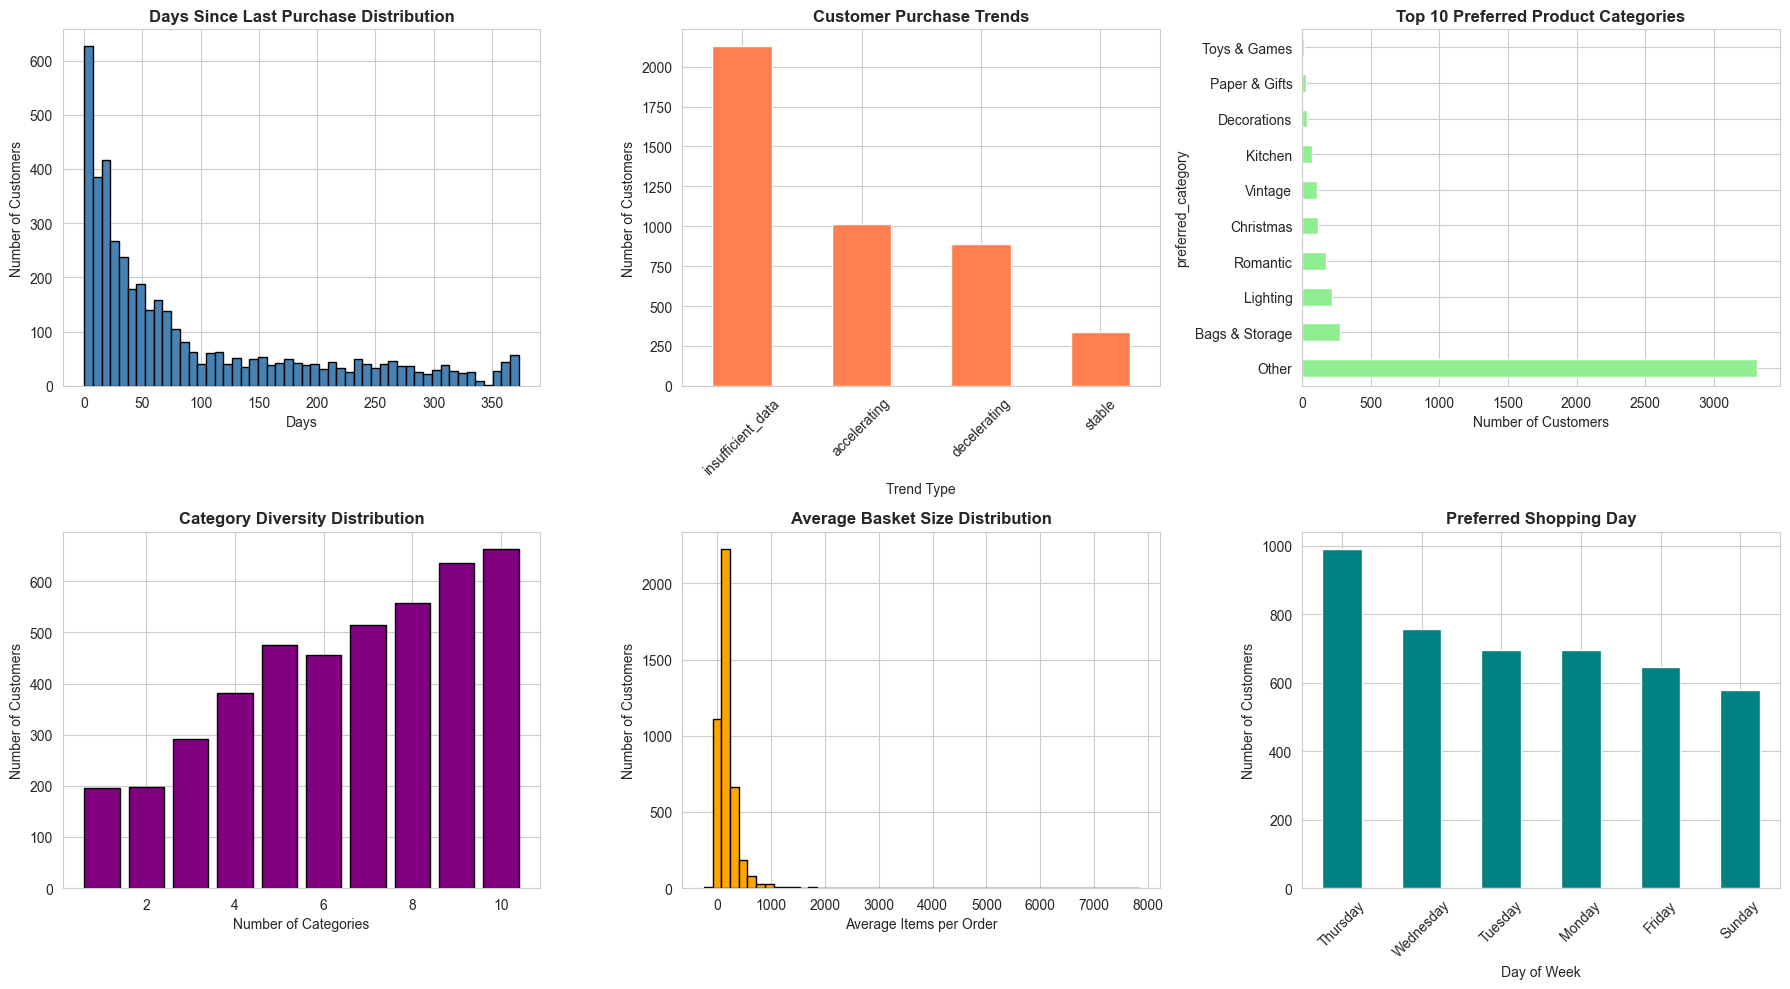

 Visualisation saved: temporal_features_analysis.png

9️⃣ Saving Updated Customer Features...
 Saved: customer_features_with_temporal.csv
 Updated database: customer_features table

🔟 Feature Summary Report...

 New Features Added:
   ✓ days_since_last_purchase
   ✓ purchase_trend
   ✓ trend_magnitude
   ✓ preferred_category
   ✓ preferred_category_spend
   ✓ category_diversity
   ✓ avg_basket_size
   ✓ std_basket_size
   ✓ min_basket_size
   ✓ max_basket_size
   ✓ avg_unique_products
   ✓ std_unique_products
   ✓ avg_basket_value
   ✓ std_basket_value
   ✓ min_basket_value
   ✓ max_basket_value
   ✓ preferred_day
   ✓ preferred_day_count
   ✓ preferred_hour
   ✓ preferred_hour_count
   ✓ preferred_season
   ✓ preferred_season_count

 Step 5: PRODUCT & TIME-BASED FEATURES COMPLETE!

 What we built:
   • Temporal features (day, month, season, hour)
   • Days since last purchase
   • Purchase acceleration/deceleration trends
   • Product category preferences
   • Basket size statistics
 

In [46]:
# ============================================================
# PRODUCT & TIME-BASED FEATURES
# ============================================================

print("="*60)
print(" PRODUCT & TIME-BASED FEATURE ENGINEERING")
print("="*60)

# ============================================================
print("\n1️⃣ Extracting Temporal Features...")

# Merge invoice_items with invoices to get dates
transactions = invoice_items.merge(
    invoices[['invoice_no', 'invoice_date', 'customer_id']], 
    on=['invoice_no', 'customer_id']
)
transactions = transactions.rename(columns={'invoice_date_y': 'invoice_date'})
transactions = transactions.drop(columns=['invoice_date_x'])

# Extract temporal components
transactions['day_of_week'] = transactions['invoice_date'].dt.dayofweek  # 0=Monday, 6=Sunday
transactions['day_name'] = transactions['invoice_date'].dt.day_name()
transactions['month'] = transactions['invoice_date'].dt.month
transactions['month_name'] = transactions['invoice_date'].dt.month_name()
transactions['hour'] = transactions['invoice_date'].dt.hour
transactions['quarter'] = transactions['invoice_date'].dt.quarter

# Create season feature
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:  # 9, 10, 11
        return 'Fall'

transactions['season'] = transactions['month'].apply(get_season)

print("   ✓ Extracted: day_of_week, month, season, hour, quarter")
print(f"   ✓ Total transactions with dates: {len(transactions):,}")

# ============================================================
print("\n2️⃣ Calculating Days Since Last Purchase (per customer)...")

# Get the reference date (last date in dataset)
reference_date = transactions['invoice_date'].max()
print(f"   Reference date: {reference_date}")

# Calculate days since last purchase for each customer
customer_last_purchase = transactions.groupby('customer_id')['invoice_date'].max().reset_index()
customer_last_purchase.columns = ['customer_id', 'last_purchase_date']
customer_last_purchase['days_since_last_purchase'] = (
    reference_date - customer_last_purchase['last_purchase_date']
).dt.days

print(f"   ✓ Average days since last purchase: {customer_last_purchase['days_since_last_purchase'].mean():.1f} days")
print(f"   ✓ Max days since last purchase: {customer_last_purchase['days_since_last_purchase'].max()} days")

# ============================================================
print("\n3️⃣ Identifying Purchase Acceleration/Deceleration Trends...")

# Calculate time between consecutive purchases for each customer
customer_purchase_dates = transactions.groupby('customer_id')['invoice_date'].apply(
    lambda x: x.sort_values().unique()
).reset_index()

def calculate_purchase_trend(dates):
    """Calculate if purchase frequency is accelerating or decelerating"""
    if len(dates) < 3:
        return 'insufficient_data', 0
    
    # Calculate gaps between consecutive purchases
    gaps = [(dates[i+1] - dates[i]).days for i in range(len(dates)-1)]
    
    if len(gaps) < 2:
        return 'insufficient_data', 0
    
    # Compare first half vs second half of gaps
    mid = len(gaps) // 2
    first_half_avg = np.mean(gaps[:mid])
    second_half_avg = np.mean(gaps[mid:])
    
    # If gaps are getting smaller, customer is accelerating (buying more frequently)
    if first_half_avg > second_half_avg * 1.2:  # 20% threshold
        return 'accelerating', second_half_avg - first_half_avg
    elif second_half_avg > first_half_avg * 1.2:
        return 'decelerating', second_half_avg - first_half_avg
    else:
        return 'stable', 0

# Apply trend calculation
customer_purchase_dates[['purchase_trend', 'trend_magnitude']] = customer_purchase_dates['invoice_date'].apply(
    lambda x: pd.Series(calculate_purchase_trend(x))
)

print("   ✓ Purchase trend analysis complete")
print(f"\n   Customer Purchase Trends:")
print(customer_purchase_dates['purchase_trend'].value_counts())

# ============================================================
print("\n4️⃣ Creating Product Category Preferences per Customer...")

# First, extract product categories from description
# For this dataset, we'll create simple categories based on keywords
def categorize_product(description):
    """Categorise products based on description keywords"""
    if pd.isna(description):
        return 'Unknown'
    
    desc_lower = str(description).lower()
    
    if any(word in desc_lower for word in ['christmas', 'santa', 'xmas']):
        return 'Christmas'
    elif any(word in desc_lower for word in ['bag', 'lunch box', 'basket']):
        return 'Bags & Storage'
    elif any(word in desc_lower for word in ['candle', 'light', 'lantern']):
        return 'Lighting'
    elif any(word in desc_lower for word in ['heart', 'love', 'valentine']):
        return 'Romantic'
    elif any(word in desc_lower for word in ['vintage', 'retrospot', 'retro']):
        return 'Vintage'
    elif any(word in desc_lower for word in ['kitchen', 'tea', 'cup', 'mug', 'plate']):
        return 'Kitchen'
    elif any(word in desc_lower for word in ['toy', 'game', 'doll', 'children']):
        return 'Toys & Games'
    elif any(word in desc_lower for word in ['paper', 'card', 'wrap', 'gift']):
        return 'Paper & Gifts'
    elif any(word in desc_lower for word in ['decoration', 'ornament', 'bunting']):
        return 'Decorations'
    else:
        return 'Other'

# Add categories to products table
products['category'] = products['description'].apply(categorize_product)

# Merge categories into transactions
transactions = transactions.merge(
    products[['stock_code', 'category']], 
    on='stock_code', 
    how='left'
)

print("   ✓ Product categories created:")
print(transactions['category'].value_counts())

# Calculate customer category preferences
customer_category_prefs = transactions.groupby(['customer_id', 'category']).agg({
    'quantity': 'sum',
    'line_total': 'sum'
}).reset_index()

# Find top category per customer (by revenue)
customer_top_category = customer_category_prefs.loc[
    customer_category_prefs.groupby('customer_id')['line_total'].idxmax()
][['customer_id', 'category', 'line_total']]
customer_top_category.columns = ['customer_id', 'preferred_category', 'preferred_category_spend']

# Calculate category diversity (how many different categories customer buys from)
customer_category_diversity = customer_category_prefs.groupby('customer_id')['category'].nunique().reset_index()
customer_category_diversity.columns = ['customer_id', 'category_diversity']

print(f"\n   ✓ Top 5 preferred categories:")
print(customer_top_category['preferred_category'].value_counts().head())
print(f"\n   ✓ Average category diversity: {customer_category_diversity['category_diversity'].mean():.1f} categories per customer")

# ============================================================
print("\n5️⃣ Calculating Basket Size Statistics...")

# Aggregate by invoice (basket level)
basket_stats = transactions.groupby(['customer_id', 'invoice_no']).agg({
    'quantity': 'sum',           # Total items in basket
    'stock_code': 'nunique',     # Unique products in basket
    'line_total': 'sum'          # Total basket value
}).reset_index()

basket_stats.columns = ['customer_id', 'invoice_no', 'total_items', 'unique_products', 'basket_value']

# Calculate per-customer basket statistics
customer_basket_stats = basket_stats.groupby('customer_id').agg({
    'total_items': ['mean', 'std', 'min', 'max'],
    'unique_products': ['mean', 'std'],
    'basket_value': ['mean', 'std', 'min', 'max']
}).reset_index()

# Flatten column names
customer_basket_stats.columns = [
    'customer_id',
    'avg_basket_size', 'std_basket_size', 'min_basket_size', 'max_basket_size',
    'avg_unique_products', 'std_unique_products',
    'avg_basket_value', 'std_basket_value', 'min_basket_value', 'max_basket_value'
]

print(f"   ✓ Average basket size: {customer_basket_stats['avg_basket_size'].mean():.1f} items")
print(f"   ✓ Average unique products per basket: {customer_basket_stats['avg_unique_products'].mean():.1f}")
print(f"   ✓ Average basket value: ${customer_basket_stats['avg_basket_value'].mean():.2f}")

# ============================================================
print("\n6️⃣ Creating Temporal Behaviour Features per Customer...")

# Preferred shopping day
customer_preferred_day = transactions.groupby(['customer_id', 'day_name']).size().reset_index(name='purchase_count')
customer_preferred_day = customer_preferred_day.loc[
    customer_preferred_day.groupby('customer_id')['purchase_count'].idxmax()
][['customer_id', 'day_name', 'purchase_count']]
customer_preferred_day.columns = ['customer_id', 'preferred_day', 'preferred_day_count']

# Preferred shopping hour
customer_preferred_hour = transactions.groupby(['customer_id', 'hour']).size().reset_index(name='purchase_count')
customer_preferred_hour = customer_preferred_hour.loc[
    customer_preferred_hour.groupby('customer_id')['purchase_count'].idxmax()
][['customer_id', 'hour', 'purchase_count']]
customer_preferred_hour.columns = ['customer_id', 'preferred_hour', 'preferred_hour_count']

# Most active season
customer_preferred_season = transactions.groupby(['customer_id', 'season']).size().reset_index(name='purchase_count')
customer_preferred_season = customer_preferred_season.loc[
    customer_preferred_season.groupby('customer_id')['purchase_count'].idxmax()
][['customer_id', 'season', 'purchase_count']]
customer_preferred_season.columns = ['customer_id', 'preferred_season', 'preferred_season_count']

print("   ✓ Temporal behaviour features created")

# ============================================================
print("\n7️⃣ Combining All Time-Based Features...")

# Start with customer_features from Week 2 (or create base if doesn't exist)
# If customer_features doesn't exist, create a base from customers table
if 'customer_features' not in locals():
    customer_features = customers[['customer_id']].copy()

# Merge all time-based features
customer_features = customer_features.merge(customer_last_purchase[['customer_id', 'days_since_last_purchase']], 
                                            on='customer_id', how='left')
customer_features = customer_features.merge(customer_purchase_dates[['customer_id', 'purchase_trend', 'trend_magnitude']], 
                                            on='customer_id', how='left')
customer_features = customer_features.merge(customer_top_category, on='customer_id', how='left')
customer_features = customer_features.merge(customer_category_diversity, on='customer_id', how='left')
customer_features = customer_features.merge(customer_basket_stats, on='customer_id', how='left')
customer_features = customer_features.merge(customer_preferred_day, on='customer_id', how='left')
customer_features = customer_features.merge(customer_preferred_hour, on='customer_id', how='left')
customer_features = customer_features.merge(customer_preferred_season, on='customer_id', how='left')

print(f"\n Total features now: {customer_features.shape[1]} columns")
print(f" Total customers: {len(customer_features):,}")

# ============================================================
print("\n8️⃣ Visualising Time-Based Features...")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Days since last purchase distribution
axes[0, 0].hist(customer_features['days_since_last_purchase'], bins=50, color='steelblue', edgecolor='black')
axes[0, 0].set_title('Days Since Last Purchase Distribution', fontweight='bold')
axes[0, 0].set_xlabel('Days')
axes[0, 0].set_ylabel('Number of Customers')

# 2. Purchase trends
customer_features['purchase_trend'].value_counts().plot(kind='bar', ax=axes[0, 1], color='coral')
axes[0, 1].set_title('Customer Purchase Trends', fontweight='bold')
axes[0, 1].set_xlabel('Trend Type')
axes[0, 1].set_ylabel('Number of Customers')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Preferred categories
customer_features['preferred_category'].value_counts().head(10).plot(kind='barh', ax=axes[0, 2], color='lightgreen')
axes[0, 2].set_title('Top 10 Preferred Product Categories', fontweight='bold')
axes[0, 2].set_xlabel('Number of Customers')

# 4. Category diversity
category_counts = customer_features['category_diversity'].value_counts().sort_index()

axes[1, 0].bar(category_counts.index,
               category_counts.values,
               color='purple',
               edgecolor='black')

axes[1, 0].set_title('Category Diversity Distribution', fontweight='bold')
axes[1, 0].set_xlabel('Number of Categories')
axes[1, 0].set_ylabel('Number of Customers')


# 5. Average basket size
axes[1, 1].hist(customer_features['avg_basket_size'], bins=50, color='orange', edgecolor='black')
axes[1, 1].set_title('Average Basket Size Distribution', fontweight='bold')
axes[1, 1].set_xlabel('Average Items per Order')
axes[1, 1].set_ylabel('Number of Customers')

# 6. Preferred shopping day
customer_features['preferred_day'].value_counts().plot(kind='bar', ax=axes[1, 2], color='teal')
axes[1, 2].set_title('Preferred Shopping Day', fontweight='bold')
axes[1, 2].set_xlabel('Day of Week')
axes[1, 2].set_ylabel('Number of Customers')
axes[1, 2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('temporal_features_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Visualisation saved: temporal_features_analysis.png")

# ============================================================
print("\n9️⃣ Saving Updated Customer Features...")

# Save to CSV
customer_features.to_csv('customer_features_with_temporal.csv', index=False)
print(" Saved: customer_features_with_temporal.csv")

# Save to database
customer_features.to_sql('customer_features', conn, if_exists='replace', index=False)
print(" Updated database: customer_features table")

# ============================================================
print("\n🔟 Feature Summary Report...")

print("\n New Features Added:")
new_features = [
    'days_since_last_purchase',
    'purchase_trend',
    'trend_magnitude',
    'preferred_category',
    'preferred_category_spend',
    'category_diversity',
    'avg_basket_size', 'std_basket_size', 'min_basket_size', 'max_basket_size',
    'avg_unique_products', 'std_unique_products',
    'avg_basket_value', 'std_basket_value', 'min_basket_value', 'max_basket_value',
    'preferred_day', 'preferred_day_count',
    'preferred_hour', 'preferred_hour_count',
    'preferred_season', 'preferred_season_count'
]

for feature in new_features:
    if feature in customer_features.columns:
        print(f"   ✓ {feature}")

print("\n" + "="*60)
print(" Step 5: PRODUCT & TIME-BASED FEATURES COMPLETE!")
print("="*60)
print(f"""
 What we built:
   • Temporal features (day, month, season, hour)
   • Days since last purchase
   • Purchase acceleration/deceleration trends
   • Product category preferences
   • Basket size statistics
   • Shopping behaviour patterns

 Total Features: {customer_features.shape[1]} columns
 Total Customers: {len(customer_features):,}

 Ready for next phase: Feature Analysis & Selection!
""")

---
<a id='feature-analysis'></a>
# Step 6: Feature Analysis & Selection

## Goals:
- Analyse feature distributions
- Check for correlations
- Identify most predictive features
- Handle missing values and outliers

## Why This Matters:
Not all features are useful! We need to select the best ones for our ML models.

 Analysing feature correlations...



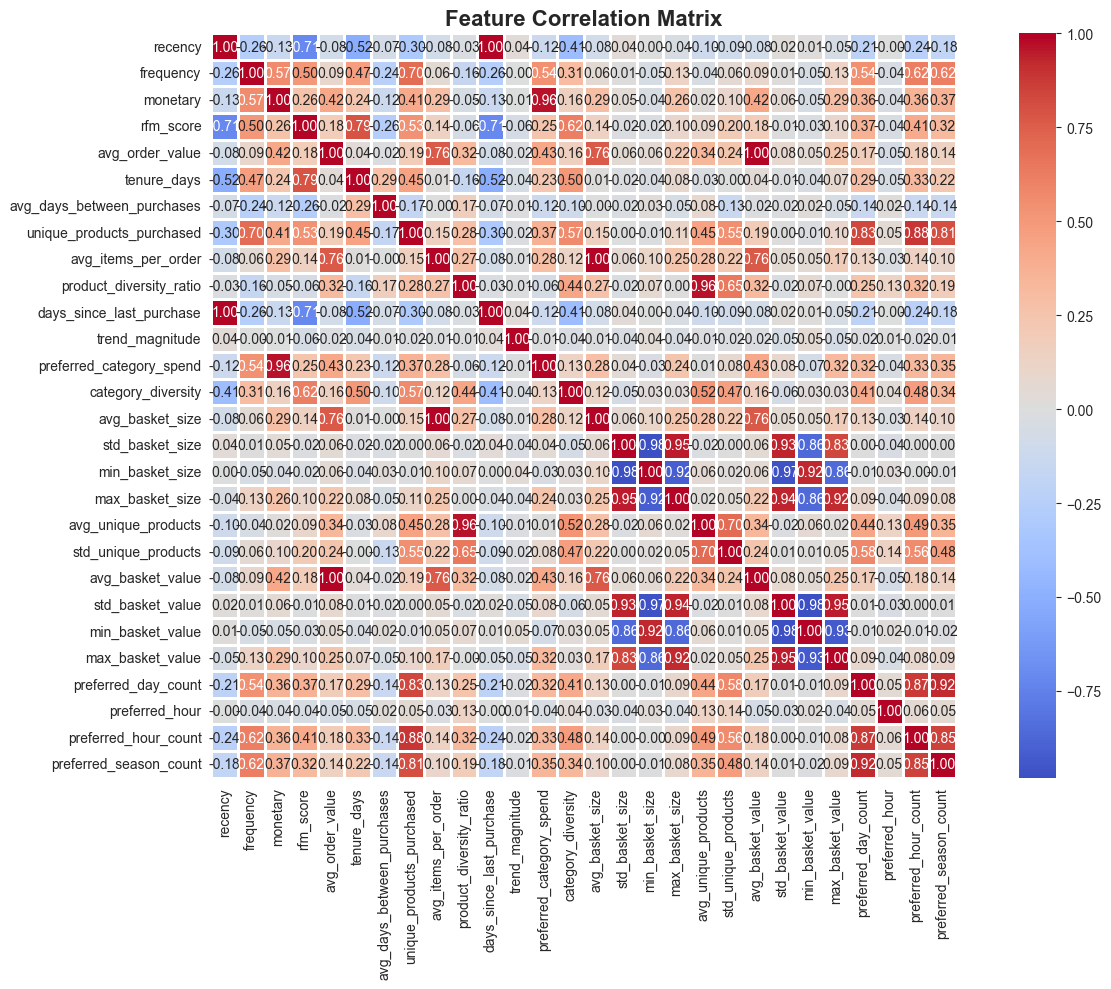


 Correlation analysis complete!

  Highly Correlated Features (>0.8):
   • recency <-> days_since_last_purchase: 1.000
   • monetary <-> preferred_category_spend: 0.964
   • avg_order_value <-> avg_basket_value: 1.000
   • unique_products_purchased <-> preferred_day_count: 0.830
   • unique_products_purchased <-> preferred_hour_count: 0.885
   • unique_products_purchased <-> preferred_season_count: 0.810
   • avg_items_per_order <-> avg_basket_size: 1.000
   • product_diversity_ratio <-> avg_unique_products: 0.964
   • std_basket_size <-> min_basket_size: -0.977
   • std_basket_size <-> max_basket_size: 0.948
   • std_basket_size <-> std_basket_value: 0.933
   • std_basket_size <-> min_basket_value: -0.859
   • std_basket_size <-> max_basket_value: 0.832
   • min_basket_size <-> max_basket_size: -0.917
   • min_basket_size <-> std_basket_value: -0.968
   • min_basket_size <-> min_basket_value: 0.924
   • min_basket_size <-> max_basket_value: -0.864
   • max_basket_size <-> std_basket_

In [47]:
# Correlation analysis #1
print(" Analysing feature correlations...\n")

# Select numeric columns only
numeric_features = customer_features.select_dtypes(include=[np.number]).columns.tolist()
numeric_features.remove('customer_id')  # Remove ID

# Calculate correlation matrix
correlation_matrix = customer_features[numeric_features].corr()

# Visualize
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1)
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_correlations.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Correlation analysis complete!")

# Identify highly correlated features
high_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.8:
            high_corr.append((correlation_matrix.columns[i], 
                            correlation_matrix.columns[j], 
                            correlation_matrix.iloc[i, j]))

if high_corr:
    print("\n  Highly Correlated Features (>0.8):")
    for feat1, feat2, corr in high_corr:
        print(f"   • {feat1} <-> {feat2}: {corr:.3f}")
    print("\n Some features must be removed from each pair to avoid multicollinearity")
else:
    print("\n No highly correlated features found!")

In [48]:
# ============================================
# FEATURE SELECTION – Removing Multicollinearity
# ============================================

print(" Reducing feature set to avoid multicollinearity...\n")

# Define selected features
selected_features = [
    'customer_id',
    'recency',
    'frequency',
    'monetary',
    'avg_order_value',
    'unique_products_purchased',
    'std_basket_value',
    'preferred_day_count'
]

# Create reduced dataset
customer_features_reduced = customer_features[selected_features].copy()

print(" Selected Features:")
for col in selected_features:
    print(f"   • {col}")

print(f"\n Original shape: {customer_features.shape}")
print(f" Reduced shape:  {customer_features_reduced.shape}")

# Optional: verify correlations again
print("\n Checking correlations in reduced feature set...\n")
display(customer_features_reduced.drop(columns=['customer_id']).corr())

 Reducing feature set to avoid multicollinearity...

 Selected Features:
   • customer_id
   • recency
   • frequency
   • monetary
   • avg_order_value
   • unique_products_purchased
   • std_basket_value
   • preferred_day_count

 Original shape: (4367, 33)
 Reduced shape:  (4367, 8)

 Checking correlations in reduced feature set...



,recency,frequency,monetary,avg_order_value,unique_products_purchased,std_basket_value,preferred_day_count
recency,1.000000,-0.259517,-0.132019,-0.080364,-0.302891,0.022567,-0.208945
frequency,-0.259517,1.000000,0.565628,0.087546,0.695569,0.013346,0.539473
monetary,-0.132019,0.565628,1.000000,0.420998,0.411949,0.062028,0.358699
avg_order_value,-0.080364,0.087546,0.420998,1.000000,0.188945,0.076888,0.174935
unique_products_purchased,-0.302891,0.695569,0.411949,0.188945,1.000000,0.001856,0.830227
std_basket_value,0.022567,0.013346,0.062028,0.076888,0.001856,1.000000,0.009468
preferred_day_count,-0.208945,0.539473,0.358699,0.174935,0.830227,0.009468,1.000000


In [ ]:
# ============================================
# REMOVE ZERO/NEGATIVE-SPEND CUSTOMERS
# ============================================

# Purpose: Remove customers with zero or negative total spend as they represent 
# data quality issues (returns-only customers, test accounts, or data errors) 
# and are not valid for ML modeling or business analysis.

print(" Removing customers with zero/negative monetary and average_order_value...\n")

initial_rows = customer_features_reduced.shape[0]

customer_features_reduced = customer_features_reduced[
    (customer_features_reduced['monetary'] > 0) &
    (customer_features_reduced['avg_order_value'] > 0)
].copy()

final_rows = customer_features_reduced.shape[0]

print(f" Removed {initial_rows - final_rows} customers")
print(f" Remaining customers: {final_rows}")

 Removing customers with zero/negative monetary and average_order_ value...

 Removed 52 customers
 Remaining customers: 4315


In [50]:
# ============================================
# HANDLE MISSING VALUES IN THE COLUMN std_basket_value BEFORE FURTHER ANALYSIS
# ============================================

print("="*60)
print("1️⃣ CHECKING FOR MISSING VALUES")
print("="*60)

missing_summary = customer_features_reduced.isnull().sum()
missing_features = missing_summary[missing_summary > 0]

if len(missing_features) > 0:
    print(f"\n  Found missing values in {len(missing_features)} features:")
    for feature, count in missing_features.items():
        pct = (count / len(customer_features_reduced)) * 100
        print(f"   • {feature}: {count:,} missing ({pct:.1f}%)")
    
    print("\n" + "="*60)
    print("2️⃣ HANDLING MISSING VALUES")
    print("="*60)
    
    # Handle std_basket_value specifically
    if 'std_basket_value' in missing_features.index:
        print(f"\n Handling std_basket_value:")
        print(f"   • Missing count: {customer_features_reduced['std_basket_value'].isnull().sum():,}")
        print(f"   • Reason: Single-purchase customers have no variation in basket value")
        print(f"   • Solution: Fill with 0 (indicates no variation)")
        
        # FIX: Proper assignment instead of inplace
        customer_features_reduced['std_basket_value'] = customer_features_reduced['std_basket_value'].fillna(0)
        
        # Verify it worked
        after_count = customer_features_reduced['std_basket_value'].isnull().sum()
        if after_count == 0:
            print(f"    Successfully filled with 0")
        else:
            print(f"     Still {after_count} missing - trying alternative method")
            # Alternative method if first attempt failed
            customer_features_reduced.loc[:, 'std_basket_value'] = customer_features_reduced['std_basket_value'].fillna(0)
    
    # Check if there are any other missing values
    remaining_missing = customer_features_reduced.isnull().sum().sum()
    
    if remaining_missing > 0:
        print(f"\n  Warning: {remaining_missing} missing values remain")
        print(customer_features_reduced.isnull().sum()[customer_features_reduced.isnull().sum() > 0])
    else:
        print(f"\n All missing values handled!")
        
else:
    print("\n No missing values found!")

print(f"\n Dataset ready for analysis:")
print(f"   • Total customers: {len(customer_features_reduced):,}")
print(f"   • Total features: {customer_features_reduced.shape[1]}")
print(f"   • Missing values: {customer_features_reduced.isnull().sum().sum()}")
print("="*60 + "\n")

1️⃣ CHECKING FOR MISSING VALUES

  Found missing values in 1 features:
   • std_basket_value: 1,282 missing (29.7%)

2️⃣ HANDLING MISSING VALUES

 Handling std_basket_value:
   • Missing count: 1,282
   • Reason: Single-purchase customers have no variation in basket value
   • Solution: Fill with 0 (indicates no variation)
    Successfully filled with 0

 All missing values handled!

 Dataset ready for analysis:
   • Total customers: 4,315
   • Total features: 8
   • Missing values: 0



 Analysing feature correlations after reduction...



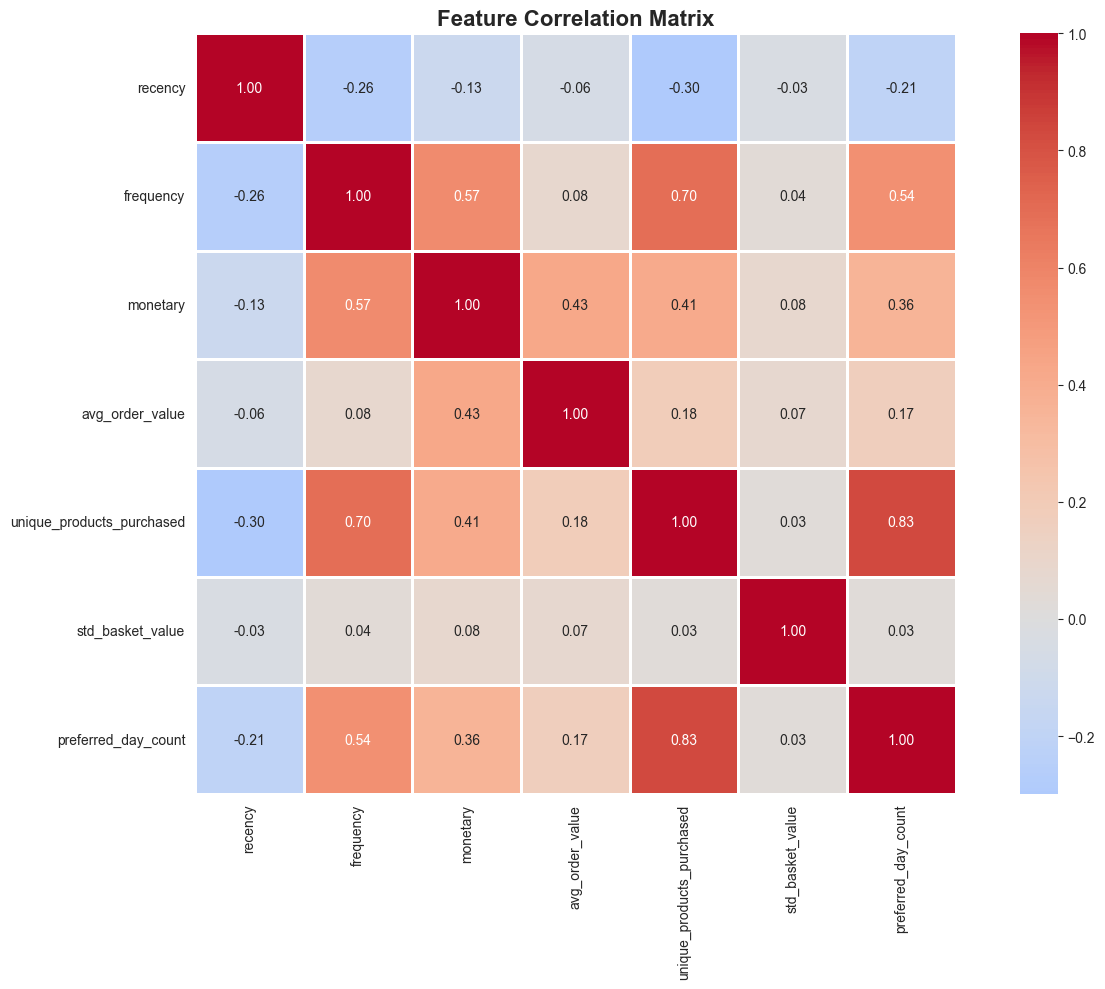


 Correlation analysis complete!

  Highly Correlated Features (>0.8):
   • unique_products_purchased <-> preferred_day_count: 0.830


In [51]:
# Now the features are clean

# Correlation analysis #2
print(" Analysing feature correlations after reduction...\n")

# Select numeric columns only
numeric_features = customer_features_reduced.select_dtypes(include=[np.number]).columns.tolist()
numeric_features.remove('customer_id')  # Remove ID

# Calculate correlation matrix
correlation_matrix = customer_features_reduced[numeric_features].corr()

# Visualize
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1)
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_correlations.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Correlation analysis complete!")

# Identify highly correlated features
high_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.8:
            high_corr.append((correlation_matrix.columns[i], 
                            correlation_matrix.columns[j], 
                            correlation_matrix.iloc[i, j]))

if high_corr:
    print("\n  Highly Correlated Features (>0.8):")
    for feat1, feat2, corr in high_corr:
        print(f"   • {feat1} <-> {feat2}: {corr:.3f}")
else:
    print("\n No highly correlated features found!")

---
<a id='feature-store'></a>
# Step 7: Final Feature Store

## Creating the Feature Store:
A feature store is a centralised repository of features ready for ML models.

## What We'll Save:
- Clean feature dataset
- Feature documentation
- Summary statistics

In [52]:
# Save feature store
print(" Saving feature store...\n")

# Save to CSV
customer_features_reduced.to_csv('customer_features_reduced.csv', index=False)
print(" Saved: customer_features_reduced.csv")

# Save to database
customer_features_reduced.to_sql('customer_features_reduced', conn, if_exists='replace', index=False)
print(" Saved to database: customer_features_reduced table")

print(f"\n Feature Store Summary:")
print(f"   • Total customers: {len(customer_features_reduced):,}")
print(f"   • Total features: {customer_features_reduced.shape[1]}")
print(f"   • Ready for ML: ")

 Saving feature store...

 Saved: customer_features_reduced.csv
 Saved to database: customer_features_reduced table

 Feature Store Summary:
   • Total customers: 4,315
   • Total features: 8
   • Ready for ML: 


In [53]:
# Create feature documentation
feature_docs = pd.DataFrame({
    'Feature': customer_features_reduced.columns,
    'Data Type': [customer_features_reduced[col].dtype for col in customer_features_reduced.columns],
    'Missing Values': [customer_features_reduced[col].isnull().sum() for col in customer_features_reduced.columns],
    'Unique Values': [customer_features_reduced[col].nunique() for col in customer_features_reduced.columns]
})

print("\n Feature Documentation:")
display(feature_docs)

# Save documentation
feature_docs.to_csv('feature_documentation_reduced.csv', index=False)
print("\n Feature documentation saved!")


 Feature Documentation:


,Feature,Data Type,Missing Values,Unique Values
0,customer_id,int64,0,4315
1,recency,int64,0,349
2,frequency,int64,0,64
3,monetary,float64,0,4244
4,avg_order_value,float64,0,4251
5,unique_products_purchased,int64,0,342
6,std_basket_value,float64,0,3024
7,preferred_day_count,int64,0,293



 Feature documentation saved!


In [54]:
# Close database connection
conn.close()
print(" Database connection closed")

print("\n" + "="*60)
print(" Phase 2 COMPLETE!")
print("="*60)
print("""
Congratulations! Completed Phase 2: Feature Engineering!

 What we built:
   • RFM Analysis (Recency, Frequency, Monetary)
   • Customer behavioural features
   • Feature correlation analysis
   • Feature store for ML models

 Deliverables Created:
   • customer_features.csv
   • feature_documentation.csv
   • rfm_distributions.png
   • feature_correlations.png

Next Phase: ML and Customer Segmentation (K-Means Clustering)

""")

 Database connection closed

 Phase 2 COMPLETE!

Congratulations! Completed Phase 2: Feature Engineering!

 What we built:
   • RFM Analysis (Recency, Frequency, Monetary)
   • Customer behavioural features
   • Feature correlation analysis
   • Feature store for ML models

 Deliverables Created:
   • customer_features.csv
   • feature_documentation.csv
   • rfm_distributions.png
   • feature_correlations.png

Next Phase: ML and Customer Segmentation (K-Means Clustering)


